### Student Information
Name:Guerrier Hantz Brunet

Student ID:1113534

GitHub ID:Hantz509

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
### Begin Assignment Here
# test code for environment setup
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
# If you get "ModuleNotFoundError: No module named 'PAMI'"
# run the following in a new Jupyter cell:
# !pip3 install PAMI
import PAMI
import umap

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

[nltk_data] Downloading package punkt to C:\Users\Hantz Brunet
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# TEST necessary for when working with external scripts
%load_ext autoreload
%autoreload 2

In [3]:
import sys
print(sys.executable) # c:\<your path to the project directory>\.venv\Scripts\python.exe
print(sys.version) #3.11.0

c:\Users\Hantz Brunet G\Documents\DM2025Labs\DM2025-Lab1-Exercise\.venv\Scripts\python.exe
3.11.13 (main, Sep 18 2025, 19:43:06) [MSC v.1944 64 bit (AMD64)]


In [4]:
# categories
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

In [5]:
# obtain the documents containing the categories provided
from sklearn.datasets import fetch_20newsgroups

twenty_train = fetch_20newsgroups(subset='train', categories=categories,
                                  shuffle=True, random_state=42) 
#This command also shuffles the data randomly, but with random_state we can bring the same distribution of data everytime 
#if we choose the same number, in this case "42". This is good for us, it means we can reproduce the same results every time
#we want to run the code.

In [6]:
twenty_train.data[0:2]

['From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n',
 "From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\nSubject: help: Splitting a trimming region along a mesh \nOrganization: University Of Kentucky, Dept. of Math Sciences\nLines: 28\n\n\n\n\tHi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the probl

In [7]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [8]:
len(twenty_train.data)

2257

In [9]:
len(twenty_train.filenames)

2257

In [10]:
# An example of what the subset contains
print("\n".join(twenty_train.data[0].split("\n")))

From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.



In [11]:
print(twenty_train.target_names[twenty_train.target[0]])


comp.graphics


In [12]:
twenty_train.target[0]

np.int64(1)

In [13]:
# category of first 10 documents.
twenty_train.target[0:10]

array([1, 1, 3, 3, 3, 3, 3, 2, 2, 2])

In [14]:
for t in twenty_train.target[:10]:
    print(twenty_train.target_names[t])

comp.graphics
comp.graphics
soc.religion.christian
soc.religion.christian
soc.religion.christian
soc.religion.christian
soc.religion.christian
sci.med
sci.med
sci.med


In [15]:
# Display the first 3 training examples
for i in range(3):
    print(f"Example {i+1}")
    print("\n".join(twenty_train.data[i].split("\n")))

Example 1
From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.

Example 2
From: ani@ms.uky.edu (Aniruddha B. Deglurkar)
Subject: help: Splitting a trimming region along a mesh 
Organization: University Of Kentucky, Dept. of Math Sciences
Lines: 28



	Hi,

	I have a problem, I hope some of the 'gurus' can help me solve.

	Background of the problem:
	I have a rectan

In [16]:
import pandas as pd

# my functions
import helpers.data_mining_helpers as dmh

# construct dataframe from a list
X = pd.DataFrame.from_records(dmh.format_rows(twenty_train), columns= ['text'])

In [17]:
len(X)

2257

In [18]:
X[0:2]

,text
0,From: sd345@city.ac.uk (Michael Collier) Subje...
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...


In [19]:
for t in X["text"][:2]:
    print(t)

From: sd345@city.ac.uk (Michael Collier) Subject: Converting images to HP LaserJet III? Nntp-Posting-Host: hampton Organization: The City University Lines: 14  Does anyone know of a good way (standard PC application/PD utility) to convert tif/img/tga files into LaserJet III format.  We would also like to do the same, converting to HPGL (HP plotter) files.  Please email any response.  Is this the correct group?  Thanks in advance.  Michael. --  Michael Collier (Programmer)                 The Computer Unit, Email: M.P.Collier@uk.ac.city                The City University, Tel: 071 477-8000 x3769                      London, Fax: 071 477-8565                            EC1V 0HB. 
From: ani@ms.uky.edu (Aniruddha B. Deglurkar) Subject: help: Splitting a trimming region along a mesh  Organization: University Of Kentucky, Dept. of Math Sciences Lines: 28    	Hi,  	I have a problem, I hope some of the 'gurus' can help me solve.  	Background of the problem: 	I have a rectangular mesh in the uv

In [20]:
# add category to the dataframe
X['category'] = twenty_train.target

In [21]:
# add category label also
X['category_name'] = X.category.apply(lambda t: dmh.format_labels(t, twenty_train))

In [22]:
X[0:10]

,text,category,category_name
0,From: sd345@city.ac.uk (Michael Collier) Subje...,1,comp.graphics
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...,1,comp.graphics
2,From: djohnson@cs.ucsd.edu (Darin Johnson) Sub...,3,soc.religion.christian
3,From: s0612596@let.rug.nl (M.M. Zwart) Subject...,3,soc.religion.christian
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,3,soc.religion.christian
5,From: vbv@lor.eeap.cwru.edu (Virgilio (Dean) B...,3,soc.religion.christian
6,From: jodfishe@silver.ucs.indiana.edu (joseph ...,3,soc.religion.christian
7,From: aldridge@netcom.com (Jacquelin Aldridge)...,2,sci.med
8,From: geb@cs.pitt.edu (Gordon Banks) Subject: ...,2,sci.med
9,From: libman@hsc.usc.edu (Marlena Libman) Subj...,2,sci.med


In [23]:
# a simple query
X[:10][["text","category_name"]]

,text,category_name
0,From: sd345@city.ac.uk (Michael Collier) Subje...,comp.graphics
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...,comp.graphics
2,From: djohnson@cs.ucsd.edu (Darin Johnson) Sub...,soc.religion.christian
3,From: s0612596@let.rug.nl (M.M. Zwart) Subject...,soc.religion.christian
4,From: stanly@grok11.columbiasc.ncr.com (stanly...,soc.religion.christian
5,From: vbv@lor.eeap.cwru.edu (Virgilio (Dean) B...,soc.religion.christian
6,From: jodfishe@silver.ucs.indiana.edu (joseph ...,soc.religion.christian
7,From: aldridge@netcom.com (Jacquelin Aldridge)...,sci.med
8,From: geb@cs.pitt.edu (Gordon Banks) Subject: ...,sci.med
9,From: libman@hsc.usc.edu (Marlena Libman) Subj...,sci.med


In [24]:

X[-10:]

,text,category,category_name
2247,From: daniels@math.ufl.edu (TV's Big Dealer) S...,3,soc.religion.christian
2248,"From: ""danny hawrysio"" <danny.hawrysio@canrem....",1,comp.graphics
2249,From: shellgate!llo@uu4.psi.com (Larry L. Over...,3,soc.religion.christian
2250,From: ingles@engin.umich.edu (Ray Ingles) Subj...,0,alt.atheism
2251,From: Mark-Tarbell@suite.com Subject: Amniocen...,2,sci.med
2252,From: roos@Operoni.Helsinki.FI (Christophe Roo...,2,sci.med
2253,From: mhollowa@ic.sunysb.edu (Michael Holloway...,2,sci.med
2254,From: sasghm@theseus.unx.sas.com (Gary Merrill...,2,sci.med
2255,From: Dan Wallach <dwallach@cs.berkeley.edu> S...,2,sci.med
2256,From: dyer@spdcc.com (Steve Dyer) Subject: Re:...,2,sci.med


In [25]:
# using loc (by label)
X.loc[:10, 'text']

0     From: sd345@city.ac.uk (Michael Collier) Subje...
1     From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...
2     From: djohnson@cs.ucsd.edu (Darin Johnson) Sub...
3     From: s0612596@let.rug.nl (M.M. Zwart) Subject...
4     From: stanly@grok11.columbiasc.ncr.com (stanly...
5     From: vbv@lor.eeap.cwru.edu (Virgilio (Dean) B...
6     From: jodfishe@silver.ucs.indiana.edu (joseph ...
7     From: aldridge@netcom.com (Jacquelin Aldridge)...
8     From: geb@cs.pitt.edu (Gordon Banks) Subject: ...
9     From: libman@hsc.usc.edu (Marlena Libman) Subj...
10    From: anasaz!karl@anasazi.com (Karl Dussik) Su...
Name: text, dtype: object

In [26]:
# using iloc (by position)
X.iloc[:10, 0]

0    From: sd345@city.ac.uk (Michael Collier) Subje...
1    From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...
2    From: djohnson@cs.ucsd.edu (Darin Johnson) Sub...
3    From: s0612596@let.rug.nl (M.M. Zwart) Subject...
4    From: stanly@grok11.columbiasc.ncr.com (stanly...
5    From: vbv@lor.eeap.cwru.edu (Virgilio (Dean) B...
6    From: jodfishe@silver.ucs.indiana.edu (joseph ...
7    From: aldridge@netcom.com (Jacquelin Aldridge)...
8    From: geb@cs.pitt.edu (Gordon Banks) Subject: ...
9    From: libman@hsc.usc.edu (Marlena Libman) Subj...
Name: text, dtype: object

In [27]:
import re
import pandas as pd
import numpy as np

try:
    docs = twenty_train.data
    y = twenty_train.target
    names = twenty_train.target_names
except NameError:
    # Fallback: load a small subset quickly (change data_home if you cached locally)
    from sklearn.datasets import fetch_20newsgroups
    categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
    twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
    docs = twenty_train.data
    y = twenty_train.target
    names = twenty_train.target_names

df = pd.DataFrame({
    "text": docs,
    "target": y
})
df["target_name"] = df["target"].map(dict(enumerate(names)))

# Some handy derived columns for querying
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().map(len)
df["has_email"] = df["text"].str.contains(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", regex=True)
df["has_url"]   = df["text"].str.contains(r"http[s]?://", regex=True)

df.head(3)


,text,target,target_name,n_chars,n_words,has_email,has_url
0,From: sd345@city.ac.uk (Michael Collier)\nSubj...,1,comp.graphics,686,87,True,False
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar)\...,1,comp.graphics,1004,181,True,False
2,From: djohnson@cs.ucsd.edu (Darin Johnson)\nSu...,3,soc.religion.christian,3200,568,True,False


In [28]:
# a) All comp.graphics posts with > 300 words
mask = (df["target_name"] == "comp.graphics") & (df["n_words"] > 300)
df_big_comp = df.loc[mask, ["target_name", "n_words", "text"]]
df_big_comp.head(3)


,target_name,n_words,text
50,comp.graphics,324,From: ab@nova.cc.purdue.edu (Allen B)\nSubject...
76,comp.graphics,308,From: sts@mfltd.co.uk (Steve Sherwood (x5543))...
170,comp.graphics,301,From: spworley@netcom.com (Steve Worley)\nSubj...


In [29]:
# b) Posts that mention "doctor" or "disease" (case-insensitive)
pat = r"(doctor|disease)"
df_health_terms = df[df["text"].str.contains(pat, case=False, regex=True)]
df_health_terms[["target_name", "n_words"]].head(5)

C:\Users\Hantz Brunet G\AppData\Local\Temp\ipykernel_4900\2403264578.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_health_terms = df[df["text"].str.contains(pat, case=False, regex=True)]


,target_name,n_words
5,soc.religion.christian,287
7,sci.med,504
9,sci.med,562
28,sci.med,191
30,sci.med,398


In [30]:
# Same as (a) but using DataFrame.query
df.query("target_name == 'comp.graphics' and n_words > 300")[["target_name", "n_words"]].head(5)


,target_name,n_words
50,comp.graphics,324
76,comp.graphics,308
170,comp.graphics,301
179,comp.graphics,304
186,comp.graphics,899


In [31]:
# Multiple conditions with .query + @variable interpolation
limit = 200
topic = "alt.atheism"
df.query("target_name == @topic and n_words.between(@limit, @limit*3)")[["target_name","n_words"]].head(5)


,target_name,n_words
21,alt.atheism,350
36,alt.atheism,211
37,alt.atheism,431
45,alt.atheism,453
53,alt.atheism,202


In [32]:
# a) Keep only two categories
keep = ["sci.med", "soc.religion.christian"]
df_two = df[df["target_name"].isin(keep)]
df_two["target_name"].value_counts()


target_name
soc.religion.christian    599
sci.med                   594
Name: count, dtype: int64

In [33]:
# b) Lines that contain a URL but NOT an email address
df_url_no_email = df[(df["has_url"]) & (~df["has_email"])]
df_url_no_email[["target_name","has_url","has_email"]].head(5)


,target_name,has_url,has_email


In [34]:
# a) The 10 longest posts overall
df_long = df.nlargest(10, "n_words")[["target_name","n_words","text"]]
df_long.head(10)


,target_name,n_words,text
433,comp.graphics,9168,From: tgl+@cs.cmu.edu (Tom Lane)\nSubject: JPE...
1403,alt.atheism,8648,From: bobbe@vice.ICO.TEK.COM (Robert Beauchain...
400,comp.graphics,8238,From: nfotis@ntua.gr (Nick C. Fotis)\nSubject:...
1890,comp.graphics,7939,From: nfotis@ntua.gr (Nick C. Fotis)\nSubject:...
768,comp.graphics,6789,From: nfotis@ntua.gr (Nick C. Fotis)\nSubject:...
971,alt.atheism,5226,From: mathew <mathew@mantis.co.uk>\nSubject: A...
1401,sci.med,5010,From: david@stat.com (David Dodell)\nSubject: ...
1596,alt.atheism,4733,From: mathew <mathew@mantis.co.uk>\nSubject: A...
1705,sci.med,4568,From: david@stat.com (David Dodell)\nSubject: ...
1103,sci.med,4407,From: noring@netcom.com (Jon Noring)\nSubject:...


In [35]:
# b) Random sample of 5 sci.med posts for manual inspection
df[(df["target_name"]=="sci.med")].sample(5, random_state=0)[["target_name","n_words","text"]]


,target_name,n_words,text
872,sci.med,216,From: geb@cs.pitt.edu (Gordon Banks)\nSubject:...
479,sci.med,38,From: RICK@ysub.ysu.edu (Rick Marsico)\nSubjec...
1579,sci.med,60,From: Gia Kiria <gkiria@kiria.kheta.georgia.s...
324,sci.med,184,From: geb@cs.pitt.edu (Gordon Banks)\nSubject:...
627,sci.med,205,From: geb@cs.pitt.edu (Gordon Banks)\nSubject:...


In [36]:
# Show the first 5 rows from every 10th sci.med document
X[X["category_name"] == "sci.med"][::10][:5]


,text,category,category_name
7,From: aldridge@netcom.com (Jacquelin Aldridge)...,2,sci.med
49,From: jimj@contractor.EBay.Sun.COM (Jim Jones)...,2,sci.med
82,From: jason@ab20.larc.nasa.gov (Jason Austin) ...,2,sci.med
118,From: rogers@calamari.hi.com (Andrew Rogers) S...,2,sci.med
142,From: lady@uhunix.uhcc.Hawaii.Edu (Lee Lady) S...,2,sci.med


In [37]:
# check missing values
X.isnull()

,text,category,category_name
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
2252,False,False,False
2253,False,False,False
2254,False,False,False
2255,False,False,False


In [38]:
X.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,category,category_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


In [39]:
# Check for missing values row by row using a custom function
X.isnull().apply(lambda x: dmh.check_missing_values(x), axis=1)

0       (The amoung of missing records is: , 0)
1       (The amoung of missing records is: , 0)
2       (The amoung of missing records is: , 0)
3       (The amoung of missing records is: , 0)
4       (The amoung of missing records is: , 0)
                         ...                   
2252    (The amoung of missing records is: , 0)
2253    (The amoung of missing records is: , 0)
2254    (The amoung of missing records is: , 0)
2255    (The amoung of missing records is: , 0)
2256    (The amoung of missing records is: , 0)
Length: 2257, dtype: object

In [40]:

dummy_series = pd.Series(["dummy_record", 1], index=["text", "category"])

In [41]:
dummy_series

text        dummy_record
category               1
dtype: object

In [42]:
dummy_series.to_frame().T
# .to_frame() -> Convert Series to DataFrame
# .T          -> Transpose

,text,category
0,dummy_record,1


In [43]:
result_with_series = pd.concat([X, dummy_series.to_frame().T], ignore_index=True)

In [44]:
# check if the records was commited into result
len(result_with_series)

2258

In [45]:

result_with_series.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,category,category_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [46]:
# dummy record as dictionary format
dummy_dict = [{'text': 'dummy_record',
               'category': 1
              }]

In [47]:

X = pd.concat([X, pd.DataFrame(dummy_dict)], ignore_index=True)

In [48]:

len(X)

2258

In [49]:
X.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,category,category_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,1


In [50]:
X.dropna(inplace=True)

In [51]:
X.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,category,category_name
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


In [54]:
import numpy as np
import pandas as pd

# Recreate the original dataset
NA_dict = [
    {'id': 'A', 'missing_example': np.nan},
    {'id': 'B', 'missing_example': ''},
    {'id': 'C', 'missing_example': 'NaN'},
    {'id': 'D', 'missing_example': 'None'},
    {'id': 'E', 'missing_example': None},
    {'id': 'F', 'missing_example': ' '}
]

NA_df = pd.DataFrame(NA_dict, columns=['id', 'missing_example'])
print("Original DataFrame:")
print(NA_df)

# Normalize string placeholders into real NaN
NA_df['missing_example'] = NA_df['missing_example'].replace(['NaN', 'None', '', ' '], np.nan)

print("\nAfter Replacement:")
print(NA_df)

# Now check for missing values
print("\nCheck with isnull():")
print(NA_df['missing_example'].isnull())


Original DataFrame:
  id missing_example
0  A             NaN
1  B                
2  C             NaN
3  D            None
4  E            None
5  F                

After Replacement:
  id  missing_example
0  A              NaN
1  B              NaN
2  C              NaN
3  D              NaN
4  E              NaN
5  F              NaN

Check with isnull():
0    True
1    True
2    True
3    True
4    True
5    True
Name: missing_example, dtype: bool


C:\Users\Hantz Brunet G\AppData\Local\Temp\ipykernel_4900\3130865823.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  NA_df['missing_example'] = NA_df['missing_example'].replace(['NaN', 'None', '', ' '], np.nan)


In [55]:
X.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2252    False
2253    False
2254    False
2255    False
2256    False
Length: 2257, dtype: bool

In [56]:
sum(X.duplicated())

0

In [57]:
sum(X.duplicated('text'))

0

In [58]:
dummy_duplicate_dict = [{
                             'text': 'dummy record',
                             'category': 1, 
                             'category_name': "dummy category"
                        },
                        {
                             'text': 'dummy record',
                             'category': 1, 
                             'category_name': "dummy category"
                        }]

In [59]:
X = pd.concat([X, pd.DataFrame(dummy_duplicate_dict)], ignore_index=True)

In [60]:
len(X)

2259

In [61]:

sum(X.duplicated())

1

In [62]:
X.drop_duplicates(keep=False, inplace=True) # inplace applies changes directly on our dataframe

In [63]:

len(X)

2257

In [64]:
X_sample = X.sample(n=1000) #random state

In [65]:

len(X_sample)

1000

In [66]:
X_sample[0:4]

,text,category,category_name
1076,From: johnh@jhunix.hcf.jhu.edu (John J Humpal)...,1,comp.graphics
1282,From: Christopher.S.Weinberger@williams.edu (G...,3,soc.religion.christian
361,From: orourke@sophia.smith.edu (Joseph O'Rourk...,1,comp.graphics
690,From: srlnjal@grace.cri.nz Subject: CorelDraw ...,1,comp.graphics


In [67]:
import pandas as pd
import numpy as np

def compare_frames(A: pd.DataFrame, B: pd.DataFrame, key: str | None = None, sample_rows: int = 5):
    print("=== SHAPE ===")
    print(f"X        : {A.shape}")
    print(f"X_sample : {B.shape}")
    print(f"Δ rows   : {B.shape[0]-A.shape[0]}")
    print(f"Δ cols   : {B.shape[1]-A.shape[1]}")
    print()

    print("=== COLUMNS ===")
    cols_A, cols_B = set(A.columns), set(B.columns)
    added   = sorted(cols_B - cols_A)
    removed = sorted(cols_A - cols_B)
    common  = sorted(cols_A & cols_B)
    print(f"Added   ({len(added)}): {added}")
    print(f"Removed ({len(removed)}): {removed}")
    print(f"Common  ({len(common)}): {common[:10]}{' ...' if len(common)>10 else ''}")
    print()

    if common:
        print("=== DTYPE CHANGES (common columns) ===")
        dtype_changes = []
        for c in common:
            if A[c].dtype != B[c].dtype:
                dtype_changes.append((c, A[c].dtype, B[c].dtype))
        if dtype_changes:
            for c, da, db in dtype_changes:
                print(f"- {c}: {da}  →  {db}")
        else:
            print("No dtype changes detected.")
        print()

        print("=== NULL COUNT Δ (B - A) for common columns (top 10 by absolute change) ===")
        null_delta = (
            pd.Series({c: B[c].isna().sum() - A[c].isna().sum() for c in common})
              .sort_values(key=lambda s: s.abs(), ascending=False)
        )
        print(null_delta.head(10))
        print()

        print("=== NUNIQUE Δ (B - A) for common columns (top 10 by absolute change) ===")
        nunique_delta = (
            pd.Series({c: B[c].nunique(dropna=True) - A[c].nunique(dropna=True) for c in common})
              .sort_values(key=lambda s: s.abs(), ascending=False)
        )
        print(nunique_delta.head(10))
        print()

    if key and key in A.columns and key in B.columns:
        print(f"=== ROW MEMBERSHIP USING KEY='{key}' ===")
        set_A = set(A[key].dropna())
        set_B = set(B[key].dropna())
        only_in_A = list(set_A - set_B)
        only_in_B = list(set_B - set_A)
        print(f"Rows removed from X: {len(only_in_A)}")
        print(f"Rows added in X_sample: {len(only_in_B)}")
        if only_in_A[:sample_rows]:
            print("\nExamples removed from X:")
            display(A[A[key].isin(only_in_A[:sample_rows])])
        if only_in_B[:sample_rows]:
            print("\nExamples added to X_sample:")
            display(B[B[key].isin(only_in_B[:sample_rows])])
        print()

    # If shapes align and columns match, show value-level differences
    if list(A.columns) == list(B.columns) and A.shape == B.shape:
        print("=== CELL-LEVEL DIFFERENCES (first few) ===")
        diff_mask = ~(A.eq(B) | (A.isna() & B.isna()))
        if diff_mask.any().any():
            # show up to a few rows/cols with differences
            rows, cols = np.where(diff_mask.to_numpy())
            rows = list(dict.fromkeys(rows))[:sample_rows]
            cols = list(dict.fromkeys(cols))[:min(sample_rows, len(A.columns))]
            print(f"Showing up to {sample_rows} differing rows/cols:")
            display(pd.DataFrame({
                "row_index": rows,
                "column": [A.columns[j] for j in cols[:len(rows)]],
                "X_value":  [A.iloc[rows[k], cols[k]] for k in range(len(rows))],
                "X_sample_value": [B.iloc[rows[k], cols[k]] for k in range(len(rows))]
            }))
        else:
            print("No cell-level differences.")
        print()

# ---- Run the comparison (set key to an ID column name if you have one) ----
compare_frames(X, X_sample, key=None)  # e.g., key="id" if your frames have an ID column


=== SHAPE ===
X        : (2257, 3)
X_sample : (1000, 3)
Δ rows   : -1257
Δ cols   : 0

=== COLUMNS ===
Added   (0): []
Removed (0): []
Common  (3): ['category', 'category_name', 'text']

=== DTYPE CHANGES (common columns) ===
No dtype changes detected.

=== NULL COUNT Δ (B - A) for common columns (top 10 by absolute change) ===
category         0
category_name    0
text             0
dtype: int64

=== NUNIQUE Δ (B - A) for common columns (top 10 by absolute change) ===
text            -1257
category            0
category_name       0
dtype: int64



# Answer here

"""
When comparing X with X_sample, I noticed the following changes:

1. The number of rows decreased from 2257 in X to 1000 in X_sample (a reduction of 1257 rows).
2. The number of columns stayed the same (3 columns: category, category_name, and text).
3. There were no dtype changes – all columns kept the same data types.
4. No new missing values were introduced, and none were removed.
5. The set of categories remained the same (all category_name values still exist in X_sample).
6. The number of unique texts decreased by 1257, which matches the rows removed.

Conclusion: X_sample is simply a sampled (smaller) version of X. 
It keeps the same structure and categories but contains fewer documents.
"""


In [111]:
import matplotlib.pyplot as plt
%matplotlib inline

In [112]:
categories

['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

category_name
soc.religion.christian    599
sci.med                   594
comp.graphics             584
alt.atheism               480
Name: count, dtype: int64


<Axes: title={'center': 'Category distribution'}, xlabel='category_name'>

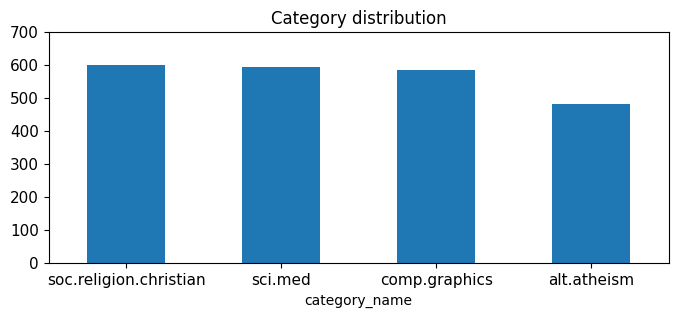

In [113]:
print(X.category_name.value_counts())

# plot barchart for X
X.category_name.value_counts().plot(kind = 'bar',
                                    title = 'Category distribution',
                                    ylim = [0, 700],        
                                    rot = 0, fontsize = 11, figsize = (8,3))

category_name
comp.graphics             275
soc.religion.christian    271
sci.med                   264
alt.atheism               190
Name: count, dtype: int64


<Axes: title={'center': 'Category distribution'}, xlabel='category_name'>

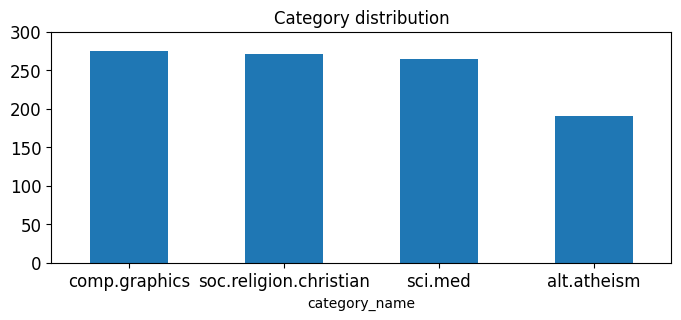

In [114]:
print(X_sample.category_name.value_counts())

# plot barchart for X_sample
X_sample.category_name.value_counts().plot(kind = 'bar',
                                           title = 'Category distribution',
                                           ylim = [0, 300], 
                                           rot = 0, fontsize = 12, figsize = (8,3))

<Axes: title={'center': 'Category distribution'}, xlabel='category_name'>

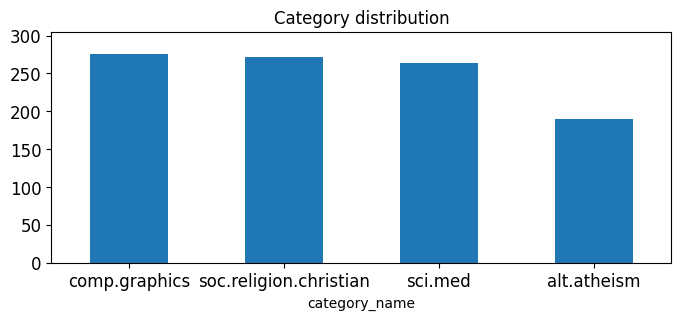

In [115]:
X_sample.category_name.value_counts().plot(
    kind='bar',
    title='Category distribution',
    ylim=(0, X_sample.category_name.value_counts().max() + 30),
    rot=0,
    fontsize=12,
    figsize=(8, 3)
)


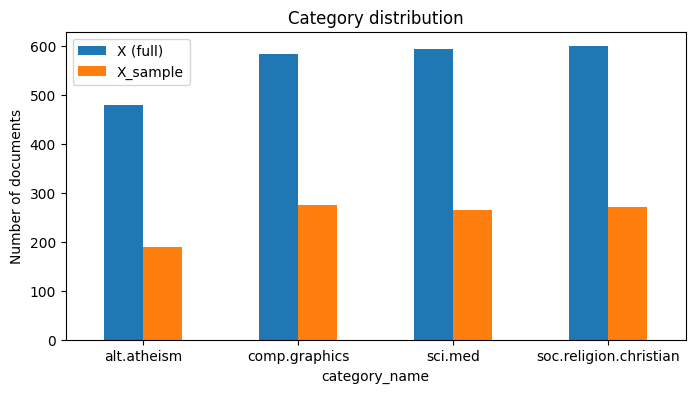

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

# Count category distribution in both dataframes
dist_X = X['category_name'].value_counts().sort_index()
dist_sample = X_sample['category_name'].value_counts().sort_index()

# Combine into one DataFrame for side-by-side plotting
dist_df = pd.DataFrame({
    'X (full)': dist_X,
    'X_sample': dist_sample
})

# Plot side by side
ax = dist_df.plot(
    kind='bar',
    figsize=(8,4),
    title='Category distribution',
    rot=0
)

ax.set_ylabel("Number of documents")
plt.show()


In [117]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to C:\Users\Hantz Brunet
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Hantz Brunet
[nltk_data]     G\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [118]:

# takes a like a minute or two to process

X['unigrams'] = X['text'].apply(lambda x: dmh.tokenize_text(x))

In [119]:
X[0:4]["unigrams"]

0    [From, :, sd345, @, city.ac.uk, (, Michael, Co...
1    [From, :, ani, @, ms.uky.edu, (, Aniruddha, B....
2    [From, :, djohnson, @, cs.ucsd.edu, (, Darin, ...
3    [From, :, s0612596, @, let.rug.nl, (, M.M, ., ...
Name: unigrams, dtype: object

In [120]:
X[0:4]

,text,category,category_name,unigrams
0,From: sd345@city.ac.uk (Michael Collier) Subje...,1,comp.graphics,"[From, :, sd345, @, city.ac.uk, (, Michael, Co..."
1,From: ani@ms.uky.edu (Aniruddha B. Deglurkar) ...,1,comp.graphics,"[From, :, ani, @, ms.uky.edu, (, Aniruddha, B...."
2,From: djohnson@cs.ucsd.edu (Darin Johnson) Sub...,3,soc.religion.christian,"[From, :, djohnson, @, cs.ucsd.edu, (, Darin, ..."
3,From: s0612596@let.rug.nl (M.M. Zwart) Subject...,3,soc.religion.christian,"[From, :, s0612596, @, let.rug.nl, (, M.M, ., ..."


In [121]:
list(X[0:1]['unigrams'])

[['From',
  ':',
  'sd345',
  '@',
  'city.ac.uk',
  '(',
  'Michael',
  'Collier',
  ')',
  'Subject',
  ':',
  'Converting',
  'images',
  'to',
  'HP',
  'LaserJet',
  'III',
  '?',
  'Nntp-Posting-Host',
  ':',
  'hampton',
  'Organization',
  ':',
  'The',
  'City',
  'University',
  'Lines',
  ':',
  '14',
  'Does',
  'anyone',
  'know',
  'of',
  'a',
  'good',
  'way',
  '(',
  'standard',
  'PC',
  'application/PD',
  'utility',
  ')',
  'to',
  'convert',
  'tif/img/tga',
  'files',
  'into',
  'LaserJet',
  'III',
  'format',
  '.',
  'We',
  'would',
  'also',
  'like',
  'to',
  'do',
  'the',
  'same',
  ',',
  'converting',
  'to',
  'HPGL',
  '(',
  'HP',
  'plotter',
  ')',
  'files',
  '.',
  'Please',
  'email',
  'any',
  'response',
  '.',
  'Is',
  'this',
  'the',
  'correct',
  'group',
  '?',
  'Thanks',
  'in',
  'advance',
  '.',
  'Michael',
  '.',
  '--',
  'Michael',
  'Collier',
  '(',
  'Programmer',
  ')',
  'The',
  'Computer',
  'Unit',
  ',',
  'Emai

In [122]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(X.text) #learn the vocabulary and return document-term matrix
print(X_counts[0])

  (np.int32(0), np.int32(14887))	1
  (np.int32(0), np.int32(29022))	1
  (np.int32(0), np.int32(8696))	4
  (np.int32(0), np.int32(4017))	2
  (np.int32(0), np.int32(33256))	2
  (np.int32(0), np.int32(21661))	3
  (np.int32(0), np.int32(9031))	3
  (np.int32(0), np.int32(31077))	1
  (np.int32(0), np.int32(9805))	2
  (np.int32(0), np.int32(17366))	1
  (np.int32(0), np.int32(32493))	4
  (np.int32(0), np.int32(16916))	2
  (np.int32(0), np.int32(19780))	2
  (np.int32(0), np.int32(17302))	2
  (np.int32(0), np.int32(23122))	1
  (np.int32(0), np.int32(25663))	1
  (np.int32(0), np.int32(16881))	1
  (np.int32(0), np.int32(16082))	1
  (np.int32(0), np.int32(23915))	1
  (np.int32(0), np.int32(32142))	5
  (np.int32(0), np.int32(33597))	2
  (np.int32(0), np.int32(20253))	1
  (np.int32(0), np.int32(587))	1
  (np.int32(0), np.int32(12051))	1
  (np.int32(0), np.int32(5201))	1
  :	:
  (np.int32(0), np.int32(25361))	1
  (np.int32(0), np.int32(25337))	1
  (np.int32(0), np.int32(12833))	2
  (np.int32(0), np.in

In [123]:
count_vect.get_feature_names_out()[14887]

'from'

In [124]:

count_vect.get_feature_names_out()[29022]

'sd345'

In [125]:

count_vect.get_feature_names_out()[8696]

'city'

In [126]:

count_vect.get_feature_names_out()[4017]

'ac'

In [127]:
analyze = count_vect.build_analyzer()
analyze("I am craving for a hawaiian pizza right now")

# tokenization, remove stop words (e.g i, a, the), create n-gram (or unigram)

['am', 'craving', 'for', 'hawaiian', 'pizza', 'right', 'now']

In [128]:
# Answer here
# How do we turn our array[0] text document into a tokenized text using the build_analyzer()?
analyze(X.text[0])

['from',
 'sd345',
 'city',
 'ac',
 'uk',
 'michael',
 'collier',
 'subject',
 'converting',
 'images',
 'to',
 'hp',
 'laserjet',
 'iii',
 'nntp',
 'posting',
 'host',
 'hampton',
 'organization',
 'the',
 'city',
 'university',
 'lines',
 '14',
 'does',
 'anyone',
 'know',
 'of',
 'good',
 'way',
 'standard',
 'pc',
 'application',
 'pd',
 'utility',
 'to',
 'convert',
 'tif',
 'img',
 'tga',
 'files',
 'into',
 'laserjet',
 'iii',
 'format',
 'we',
 'would',
 'also',
 'like',
 'to',
 'do',
 'the',
 'same',
 'converting',
 'to',
 'hpgl',
 'hp',
 'plotter',
 'files',
 'please',
 'email',
 'any',
 'response',
 'is',
 'this',
 'the',
 'correct',
 'group',
 'thanks',
 'in',
 'advance',
 'michael',
 'michael',
 'collier',
 'programmer',
 'the',
 'computer',
 'unit',
 'email',
 'collier',
 'uk',
 'ac',
 'city',
 'the',
 'city',
 'university',
 'tel',
 '071',
 '477',
 '8000',
 'x3769',
 'london',
 'fax',
 '071',
 '477',
 '8565',
 'ec1v',
 '0hb']

In [129]:
# We can check the shape of this matrix by:
X_counts.shape

(2257, 35788)

In [130]:
# We can obtain the feature names of the vectorizer, i.e., the terms
# usually on the horizontal axis
count_vect.get_feature_names_out()[0:10]

array(['00', '000', '0000', '0000001200', '000005102000', '0001',
       '000100255pixel', '00014', '000406', '0007'], dtype=object)

In [131]:
X_counts.shape

(2257, 35788)

In [132]:
# we convert from sparse array to normal array
X_counts[0:5, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [133]:
count_vect.get_feature_names_out()[0:1]

array(['00'], dtype=object)

In [134]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer and fit it on the text
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(X.text)

# 5th record (index 4, since Python uses 0-based indexing)
record = X_bow[4]

# Get the indices of nonzero entries (the words that appear in this record)
word_indices = record.nonzero()[1]

# Map indices back to words
feature_names = vectorizer.get_feature_names_out()
words_in_record = [feature_names[i] for i in word_indices]

print("Words in the 5th record:", words_in_record)


Words in the 5th record: ['from', 'subject', 'to', 'hp', 'organization', 'the', 'lines', '14', 'of', 'like', 'is', 'this', 'in', 'edu', 'which', 'for', 'made', 'then', 'it', 'as', 'there', 're', 'at', 'so', 'and', 'that', 'on', 'your', 'are', 'you', 'find', '15', 'one', 'believe', 'go', 'our', 'who', 'stanly', 'grok11', 'columbiasc', 'ncr', 'com', 'elder', 'brother', 'corp', 'columbia', 'sc', 'article', 'apr', '00', '57', '41', '1993', '28246', 'athos', 'rutgers', 'rexlex', 'fnal', 'gov', 'writes', '01', '56', '22824', 'shrum', 'hpfcso', 'fc', 'matt', '22', 'therefore', 'main', 'highways', 'many', 'invite', 'wedding', 'feast', 'hmmmmmm', 'sounds', 'theology', 'christ', 'odds', 'am', 'parable', 'jesus', 'tells', 'kingdom', 'heaven', 'unto', 'certain', 'king', 'marriage', 'his', 'son', 'clothes', 'were', 'customary', 'given', 'those', 'chose', 'attend', 'man', 'refused', 'wear', 'equalivant', 'righteousness', 'when', 'died', 'sins', 'provided', 'decision', 'put']


In [135]:
# first twenty features only
plot_x = ["term_"+str(i) for i in count_vect.get_feature_names_out()[0:20]]

In [136]:
# obtain document index
plot_y = ["doc_"+ str(i) for i in list(X.index)[0:20]]

In [137]:
plot_z = X_counts[0:20, 0:20].toarray() #X_counts[how many documents, how many terms]
plot_z

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

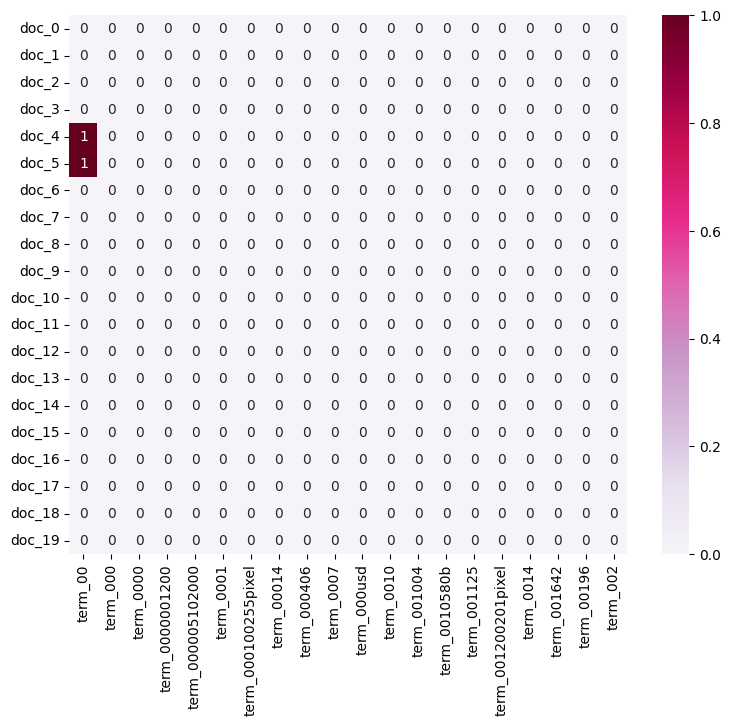

In [138]:
import seaborn as sns

df_todraw = pd.DataFrame(plot_z, columns = plot_x, index = plot_y)
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw,
                 cmap="PuRd",
                 vmin=0, vmax=1, annot=True)

Matrix shape: 2257 docs × 35788 terms
Non-zeros: 365,886  |  Sparsity: 99.547%


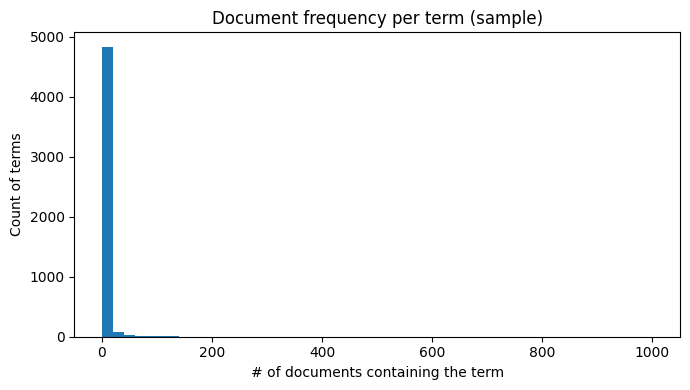

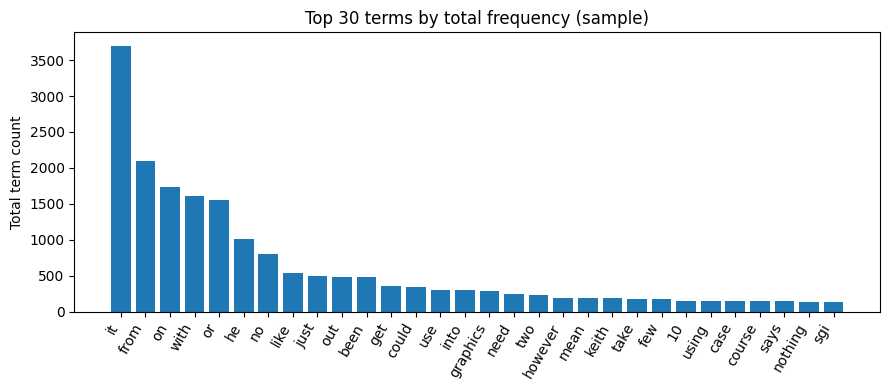

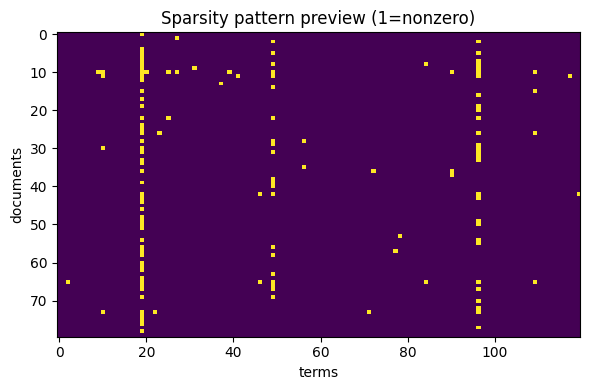

In [139]:
# ===== Exercise 11 (take home): efficient sparsity visualizations =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer

# 1) Build (or reuse) the sparse BoW matrix
try:
    X_bow
    vectorizer
except NameError:
    vectorizer = CountVectorizer()                  # tweak params if needed (min_df, stop_words, etc.)
    X_bow = vectorizer.fit_transform(X["text"])     # sparse CSR matrix (n_docs x n_terms)

n_docs, n_terms = X_bow.shape
print(f"Matrix shape: {n_docs} docs × {n_terms} terms")
nnz = X_bow.nnz
sparsity = 1 - nnz / (n_docs * n_terms)
print(f"Non-zeros: {nnz:,}  |  Sparsity: {sparsity:.3%}")

# 2) (Optional) sample to keep plots readable
DOC_SAMPLE = min(1000, n_docs)    # sample up to 1000 docs
TERM_SAMPLE = min(5000, n_terms)  # sample up to 5k terms

rng = np.random.default_rng(0)
doc_idx = rng.choice(n_docs, DOC_SAMPLE, replace=False) if DOC_SAMPLE < n_docs else np.arange(n_docs)
term_idx = rng.choice(n_terms, TERM_SAMPLE, replace=False) if TERM_SAMPLE < n_terms else np.arange(n_terms)

X_sub = X_bow[doc_idx][:, term_idx]                 # still sparse
feat = vectorizer.get_feature_names_out()[term_idx] # subset vocabulary

# 3) Fast summaries (all done in sparse)
term_counts = X_sub.sum(axis=0).A1                  # total frequency per term across sampled docs
doc_freq    = (X_sub > 0).sum(axis=0).A1            # in how many docs each term appears

# 4) Histogram of document frequency (how sparse terms are)
plt.figure(figsize=(7,4))
plt.hist(doc_freq, bins=50)
plt.title("Document frequency per term (sample)")
plt.xlabel("# of documents containing the term")
plt.ylabel("Count of terms")
plt.tight_layout()
plt.show()

# 5) Top-K frequent terms (by total counts)
K = 30
top_idx = np.argsort(term_counts)[::-1][:K]
plt.figure(figsize=(9,4))
plt.bar(range(K), term_counts[top_idx])
plt.xticks(range(K), feat[top_idx], rotation=60, ha="right")
plt.title(f"Top {K} terms by total frequency (sample)")
plt.ylabel("Total term count")
plt.tight_layout()
plt.show()

# 6) (Bonus) Heatmap preview of sparsity pattern (very small slice to stay readable)
r = min(80, X_sub.shape[0]); c = min(120, X_sub.shape[1])
preview = X_sub[:r, :c].astype(bool).astype(int).A    # dense only for small preview
plt.figure(figsize=(6,4))
plt.imshow(preview, aspect='auto', interpolation='nearest')
plt.title("Sparsity pattern preview (1=nonzero)")
plt.xlabel("terms")
plt.ylabel("documents")
plt.tight_layout()
plt.show()


In [140]:
# note this takes time to compute. You may want to reduce the amount of terms you want to compute frequencies for
term_frequencies = []
for j in range(0,X_counts.shape[1]):
    term_frequencies.append(sum(X_counts[:,j].toarray()))

#[3, 8, 5, 2, 5, 8, 2, 5, 3, 2]

In [141]:
term_frequencies = np.asarray(X_counts.sum(axis=0))[0]

In [142]:

term_frequencies[0] #sum of first term: 00

np.int64(134)

C:\Users\Hantz Brunet G\AppData\Local\Temp\ipykernel_4900\3480579971.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



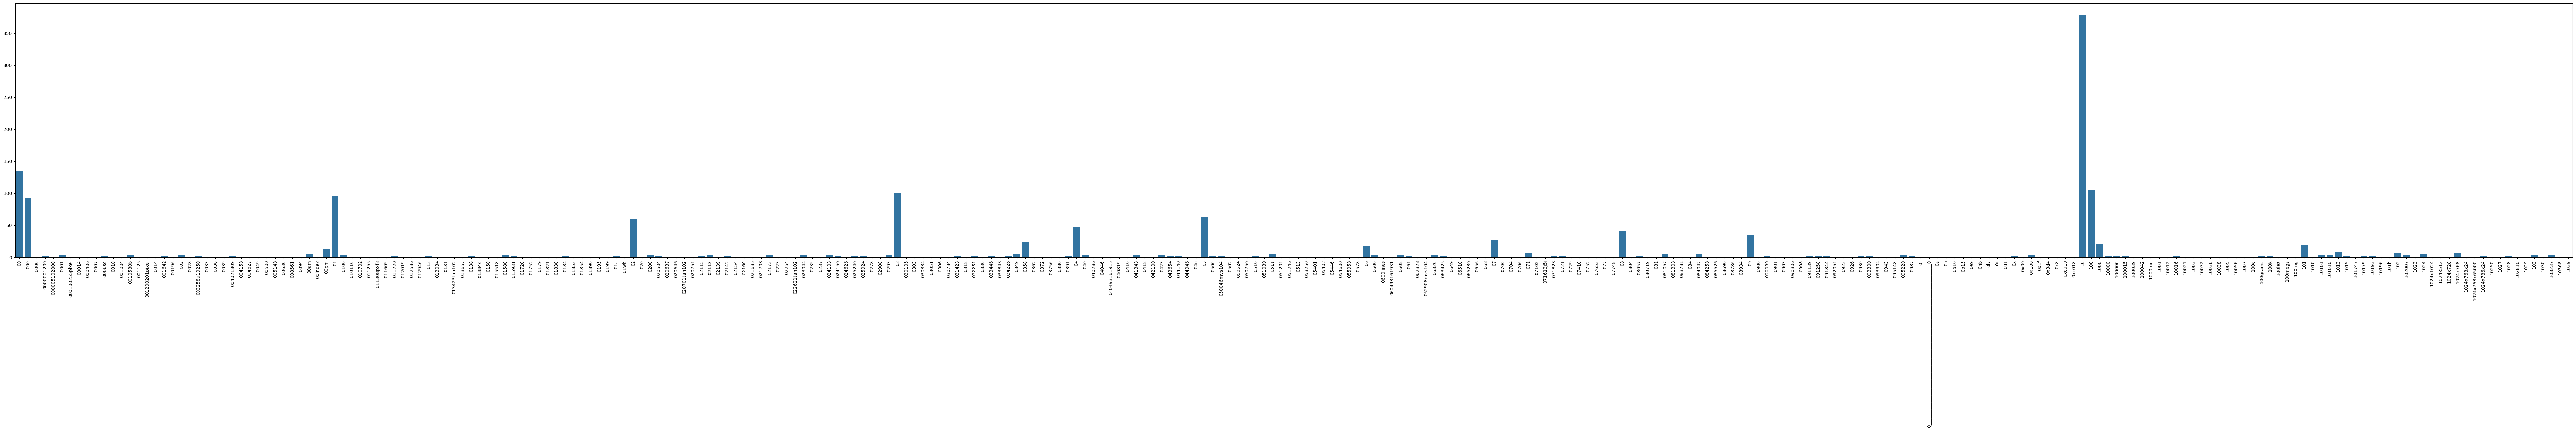

In [143]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300], 
            y=term_frequencies[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

In [144]:
# Exercise 12
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Build (or reuse) BoW
try:
    X_bow; vectorizer
except NameError:
    vectorizer = CountVectorizer()
    X_bow = vectorizer.fit_transform(X["text"])

feature_names = vectorizer.get_feature_names_out()
term_counts = np.asarray(X_bow.sum(axis=0)).ravel()

df_terms = pd.DataFrame({"term": feature_names, "count": term_counts})
df_terms = df_terms.sort_values("count", ascending=False)

import plotly.express as px
TOP = 50  # show top-N
fig = px.bar(
    df_terms.head(TOP),
    x="term", y="count",
    title=f"Top {TOP} terms (interactive)",
    labels={"term":"Term","count":"Total frequency"},
)
fig.update_layout(xaxis_tickangle=-45, bargap=0.15, height=420)
fig.show()


In [145]:
# Exercise 13
import numpy as np, pandas as pd

# a) Doc-frequency filter (appears in ≥ df_min documents)
df_min = 5
doc_freq = np.asarray((X_bow > 0).sum(axis=0)).ravel()
mask_df = doc_freq >= df_min

X_bow_df = X_bow[:, mask_df]
terms_df = vectorizer.get_feature_names_out()[mask_df]
print(f"Doc-frequency filter kept {X_bow_df.shape[1]} terms (df ≥ {df_min})")

# b) Coverage filter (keep top-K terms that cover ≥ coverage% of total counts)
term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
order = np.argsort(term_counts)[::-1]
sorted_counts = term_counts[order]
cum = np.cumsum(sorted_counts)
coverage = 0.95
K = int((cum <= coverage * cum[-1]).sum()) or 1

keep_idx = order[:K]
X_bow_cov = X_bow[:, keep_idx]
terms_cov = vectorizer.get_feature_names_out()[keep_idx]
print(f"Coverage filter kept {K} terms (≈{coverage*100:.0f}% of total counts)")

# Quick visualization of the reduced set (interactive)
import plotly.express as px
df_top = pd.DataFrame({"term": terms_cov, "count": term_counts[keep_idx]}).sort_values("count", ascending=False)
fig = px.bar(df_top.head(50), x="term", y="count", title="Reduced vocabulary (coverage filter)", labels={"term":"Term","count":"Total frequency"})
fig.update_layout(xaxis_tickangle=-45, height=420)
fig.show()


Doc-frequency filter kept 8611 terms (df ≥ 5)
Coverage filter kept 12652 terms (≈95% of total counts)


In [146]:
# Exercise 14
import numpy as np, pandas as pd, plotly.express as px

term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
order = np.argsort(term_counts)[::-1]  # sort by frequency (desc)
counts_sorted = term_counts[order]
terms_sorted = vectorizer.get_feature_names_out()[order]

df_longtail = pd.DataFrame({"rank": np.arange(1, len(counts_sorted)+1),
                            "term": terms_sorted,
                            "count": counts_sorted})

# Long-tail view: frequency vs rank (classic Zipf curve)
fig = px.line(df_longtail.head(5000), x="rank", y="count",
              title="Long tail of term frequencies (sorted by frequency)",
              labels={"rank":"Term rank (1 = most frequent)", "count":"Total frequency"})
fig.update_traces(mode="lines+markers", marker_size=2)
fig.update_layout(height=420)
fig.show()

# (Optional) bar of top N also sorted by frequency
TOP = 100
fig = px.bar(df_longtail.head(TOP), x="term", y="count",
             title=f"Top {TOP} terms (sorted by frequency)",
             labels={"term":"Term","count":"Total frequency"})
fig.update_layout(xaxis_tickangle=-60, height=450)
fig.show()


In [147]:
import math
term_frequencies_log = [math.log(i) for i in term_frequencies]

C:\Users\Hantz Brunet G\AppData\Local\Temp\ipykernel_4900\2166548998.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



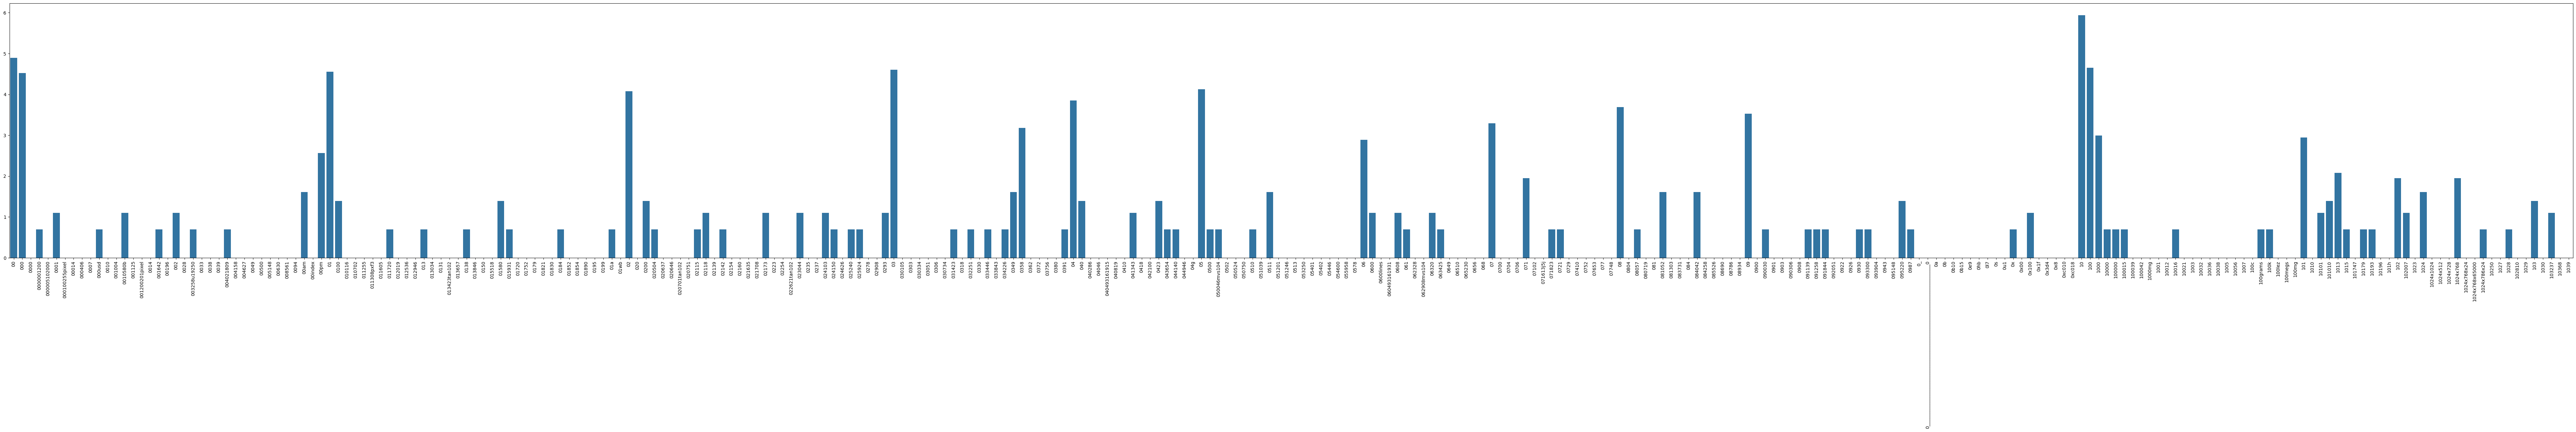

In [149]:
plt.subplots(figsize=(100, 10))
g = sns.barplot(x=count_vect.get_feature_names_out()[:300],
                y=term_frequencies_log[:300])
g.set_xticklabels(count_vect.get_feature_names_out()[:300], rotation = 90);

In [151]:
# Exercise 15 (take home): Log-scaled term frequencies
import numpy as np
import pandas as pd
import plotly.express as px

# Get raw term frequencies
term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
order = np.argsort(term_counts)[::-1]
counts_sorted = term_counts[order]
terms_sorted = vectorizer.get_feature_names_out()[order]

# Apply log transform (add +1 to avoid log(0))
counts_log = np.log1p(counts_sorted)

df_log = pd.DataFrame({
    "rank": np.arange(1, len(counts_sorted) + 1),
    "term": terms_sorted,
    "count_log": counts_log
})

# Plot the log distribution
fig = px.line(
    df_log.head(5000),
    x="rank", y="count_log",
    title="Log-scaled long tail of term frequencies",
    labels={"rank": "Term rank (1 = most frequent)", "count_log": "log(1 + frequency)"}
)
fig.update_traces(mode="lines+markers", marker_size=2)
fig.update_layout(height=420)
fig.show()


# Phase 2

In [148]:
### Begin Assignment Here